<a href="https://colab.research.google.com/github/VukasinJ-dev/car-price-prediction/blob/main/notebooks/EDA_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA analiza  

**Autor** : Vukasin Jovanovic

**Datum** : 26.08.2026

## Cilj Analize


## Uvoz potrebnih biblioteka

In [84]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Ucitavanje skupa podataka i pocetno upoznavanje

In [85]:
# Load dataset from GitHub
url = "https://raw.githubusercontent.com/VukasinJ-dev/car-price-prediction/main/data/cars.csv"
df = pd.read_csv(url)

# Print shape (number of rows and columns)
print("Dataset shape (rows, columns):", df.shape)

# Show first 5 rows
print("\nFirst 5 rows:")
display(df.head())

# Show column data types and non-null counts
print("\nDataset info:")
df.info()

Dataset shape (rows, columns): (56244, 12)

First 5 rows:


,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
0,mazda,2,5500,2008,with mileage,162000.0,petrol,1500.0,burgundy,mechanics,front-wheel drive,B
1,mazda,2,5350,2009,with mileage,120000.0,petrol,1300.0,black,mechanics,front-wheel drive,B
2,mazda,2,7000,2009,with mileage,61000.0,petrol,1500.0,silver,auto,front-wheel drive,B
3,mazda,2,3300,2003,with mileage,265000.0,diesel,1400.0,white,mechanics,front-wheel drive,B
4,mazda,2,5200,2008,with mileage,97183.0,diesel,1400.0,gray,mechanics,front-wheel drive,B



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56244 entries, 0 to 56243
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make                 56244 non-null  object 
 1   model                56244 non-null  object 
 2   priceUSD             56244 non-null  int64  
 3   year                 56244 non-null  int64  
 4   condition            56244 non-null  object 
 5   mileage(kilometers)  56244 non-null  float64
 6   fuel_type            56244 non-null  object 
 7   volume(cm3)          56197 non-null  float64
 8   color                56244 non-null  object 
 9   transmission         56244 non-null  object 
 10  drive_unit           54339 non-null  object 
 11  segment              50953 non-null  object 
dtypes: float64(2), int64(2), object(8)
memory usage: 5.1+ MB


In [86]:
df.sample(5, random_state=42)

,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
19270,mitsubishi,carisma,2050,1999,with mileage,250000.0,petrol,1800.0,blue,mechanics,front-wheel drive,M
25927,ford,fusion,4500,2006,with mileage,160000.0,petrol,1400.0,burgundy,mechanics,front-wheel drive,M
23388,mercedes-benz,e-klass,3500,1999,with mileage,485000.0,diesel,2900.0,blue,mechanics,rear drive,E
53189,bmw,x3,21000,2013,with mileage,159000.0,diesel,2000.0,black,auto,NaN,J
34058,renault,megane,3990,2002,with mileage,331700.0,diesel,1900.0,other,mechanics,front-wheel drive,C


Početnim pregledom skupa možemo videti da ne postoji veliki broj kolona sa značajnim brojem nedostajućih vrednosti. Takođe, možemo primetiti nekoliko kolona kojima je potrebno standardizovati nazive radi lakšeg budućeg rada sa podacima.

In [87]:
# Count missing values per column
print("Columns with missing values:")
missing_values = df.isna().sum()
missing_values[missing_values > 0]

Columns with missing values:


,0
volume(cm3),47
drive_unit,1905
segment,5291


In [88]:
missing_like_values = ["NaN", "nan", "NULL", "null", "None", "none", "unknown", "UNKNOWN"]

for column in df.columns:
    if df[column].dtype == "object":
        count = df[column].astype(str).str.strip().isin(missing_like_values).sum()

        if count > 0:
            print(f"{column}: {count}")

drive_unit: 1905
segment: 5291


Vidimo da samo u kolonama volume(cm3), drive_unit i segment postoje nedostajuće vrednosti. Dodatnim ispitivanjem vrednosti koje mogu izgledati kao nedostajuće, uverili smo se da je njihov broj isti.

In [89]:
df[df.isnull().any(axis=1)].sample(10)

,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
52646,chevrolet,volt,22000,2015,with mileage,157715.32,electrocar,NaN,silver,auto,front-wheel drive,NaN
30853,suzuki,kizashi,9650,2010,with mileage,161000.00,petrol,2400.0,black,auto,front-wheel drive,NaN
40344,toyota,picnic,4400,1999,with mileage,364000.00,diesel,2200.0,silver,mechanics,NaN,NaN
2115,audi,100,500,1987,with mileage,350000.00,petrol,1800.0,white,mechanics,NaN,E
48502,ford,taurus,1188,1994,with mileage,160934.00,petrol,3000.0,blue,auto,front-wheel drive,NaN
28711,renault,grand-scenic,10999,2014,with mileage,149000.00,diesel,1500.0,black,mechanics,front-wheel drive,NaN
16785,plymouth,breeze,1400,1999,with mileage,349226.78,petrol,2000.0,green,auto,front-wheel drive,NaN
50010,ford,transit-connect,13500,2016,with mileage,125000.00,diesel,1500.0,black,mechanics,front-wheel drive,NaN
30321,volkswagen,jetta,700,1990,with mileage,390000.00,petrol,1600.0,gray,mechanics,NaN,C
46141,kia,sephia,750,1996,with mileage,2977.00,petrol,1500.0,gray,mechanics,front-wheel drive,NaN


In [90]:
df.duplicated().sum()

np.int64(87)

In [91]:
df[df.duplicated()]

,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
1930,audi,100,1280,1991,with mileage,305000.0,petrol,2300.0,red,mechanics,front-wheel drive,E
2054,audi,100,2000,1988,with mileage,350000.0,petrol,2300.0,blue,mechanics,front-wheel drive,E
2140,audi,100,1100,1989,with mileage,350000.0,petrol,2300.0,burgundy,mechanics,front-wheel drive,E
2179,peugeot,106,700,2000,with mileage,27000.0,diesel,1500.0,blue,mechanics,front-wheel drive,B
4334,peugeot,406,2200,1995,with mileage,330000.0,petrol,1800.0,gray,mechanics,front-wheel drive,D
...,...,...,...,...,...,...,...,...,...,...,...,...
53694,bmw,x5,16500,2007,with mileage,265000.0,diesel,3000.0,white,auto,all-wheel drive,J
53828,bmw,x5,10000,2005,with mileage,231000.0,petrol,3000.0,black,auto,all-wheel drive,J
54264,citroen,xantia,1800,1999,with mileage,300000.0,petrol,1800.0,black,mechanics,front-wheel drive,D
55763,opel,zafira,4700,2002,with mileage,320000.0,diesel,2000.0,silver,mechanics,front-wheel drive,M


Vidimo takođe da u našem skupu podataka postoje redovi koji predstavljaju duplikate. Zbog toga bi bilo poželjno ukloniti takve redove pre treniranja modela, kako ne bi uticali na rezultate analize i sam proces treniranja modela.

## Prikaz numerickih kolona

In [92]:
numeric_columns = [
    "priceUSD",
    "year",
    "mileage(kilometers)",
    "volume(cm3)"
]
df[numeric_columns].dtypes

,0
priceUSD,int64
year,int64
mileage(kilometers),float64
volume(cm3),float64


In [93]:
df[numeric_columns].describe()

,priceUSD,year,mileage(kilometers),volume(cm3)
count,56244.000000,56244.000000,5.624400e+04,56197.000000
mean,7415.456440,2003.454840,2.443956e+05,2104.860615
std,8316.959261,8.144247,3.210307e+05,959.201633
min,48.000000,1910.000000,0.000000e+00,500.000000
25%,2350.000000,1998.000000,1.370000e+05,1600.000000
50%,5350.000000,2004.000000,2.285000e+05,1996.000000
75%,9807.500000,2010.000000,3.100000e+05,2300.000000
max,235235.000000,2019.000000,9.999999e+06,20000.000000


Vidimo neke od prvih nelogičnosti u skupu podataka. Prva je cena od svega 48 dolara, zbog čega je potrebno dodatno ispitati redove u kojima je cena niska. Druga nelogičnost odnosi se na kilometražu od skoro 10 miliona, što je veoma neuobičajena vrednost i zahteva dodatnu proveru. Poslednja je kubikaža od 20.000 cc, za koju pretpostavljamo da predstavlja grešku pri unosu podataka.

## PriceUSD prikaz

Upoznaćemo se sa vrednostima u koloni `priceUSD`, koja predstavlja ciljnu promenljivu našeg modela.


In [94]:
print(df['priceUSD'].sample(10))

5976       500
5168      5500
15840     6800
32666     6500
51317     2600
50716    32515
2628      3250
34091     2890
18447     2000
30282     5950
Name: priceUSD, dtype: int64


In [95]:
df[['make', 'model', 'priceUSD', 'year', 'mileage(kilometers)', 'volume(cm3)']].nsmallest(20, 'priceUSD')

,make,model,priceUSD,year,mileage(kilometers),volume(cm3)
5952,zaz,968,48,1910,25000.0,1100.0
40252,proton,persona,95,1997,1111.0,1600.0
5456,mazda,626,100,1986,100.0,2000.0
7314,mercedes-benz,190-w201,100,1991,2000.0,2000.0
20971,toyota,corolla,100,1988,300000.0,1300.0
23898,ford,escort,100,1986,200000.0,1300.0
24873,ford,fiesta,100,1992,1.0,1100.0
41010,nissan,primera,100,1994,300000.0,2000.0
54171,citroen,xantia,100,1995,380000.0,1800.0
7076,lada-vaz,21099,119,1992,20000.0,1500.0


Pregledom 20 najjeftinijih automobila možemo videti da većina niskih cena ima smisla kada se uzmu u obzir ostale karakteristike. Većina automobila je starija, ima veliku kilometražu ili je označena kao `for parts` ili `with damage`. Zbog toga niske vrednosti `priceUSD` nećemo za sada smatrati greškama, već ćemo dodatno proveriti nelogične vrednosti u ostalim kolonama.

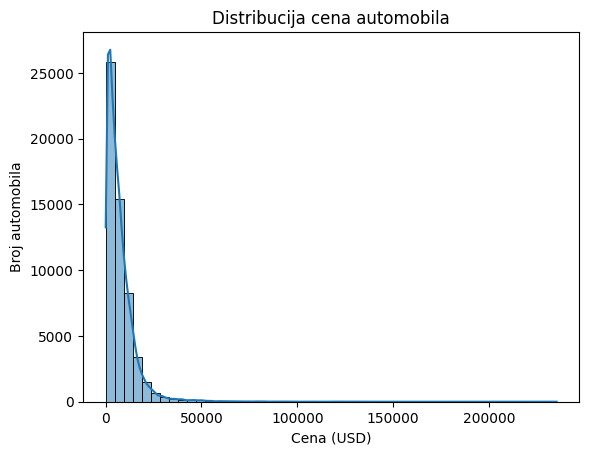

In [96]:
sns.histplot(data=df, x='priceUSD', bins=50, kde=True)

plt.title('Distribucija cena automobila')
plt.xlabel('Cena (USD)')
plt.ylabel('Broj automobila')
plt.show()

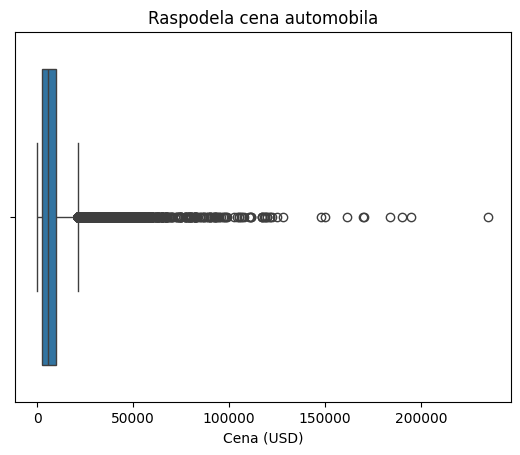

In [97]:
sns.boxplot(data=df, x='priceUSD')

plt.title('Raspodela cena automobila')
plt.xlabel('Cena (USD)')
plt.show()

Vidimo da postoji značajan broj ekstremno visokih vrednosti u koloni `priceUSD`. S obzirom na veličinu skupa podataka, određeni broj ekstremnih vrednosti je očekivan. Takođe, možemo videti da je najveći broj vrednosti, odnosno 50% centralnih vrednosti, koncentrisan bliže 0, što ukazuje na izraženu desnu asimetriju distribucije cena.

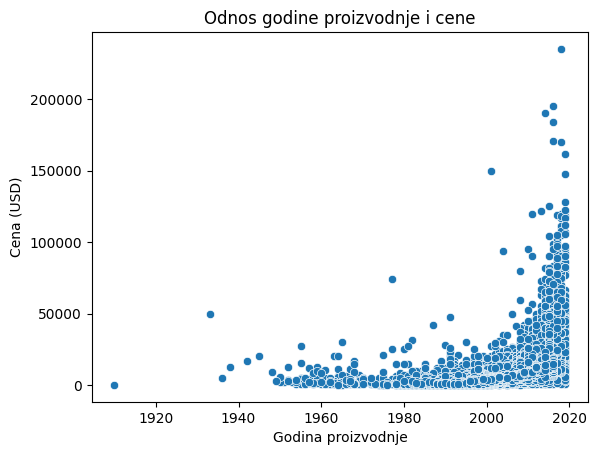

In [98]:
sns.scatterplot(data=df, x='year', y='priceUSD')

plt.title('Odnos godine proizvodnje i cene')
plt.xlabel('Godina proizvodnje')
plt.ylabel('Cena (USD)')
plt.show()

Vidimo da sa porastom godine proizvodnje automobila uglavnom raste i njegova cena, što ukazuje na pozitivnu povezanost između godine proizvodnje i cene.

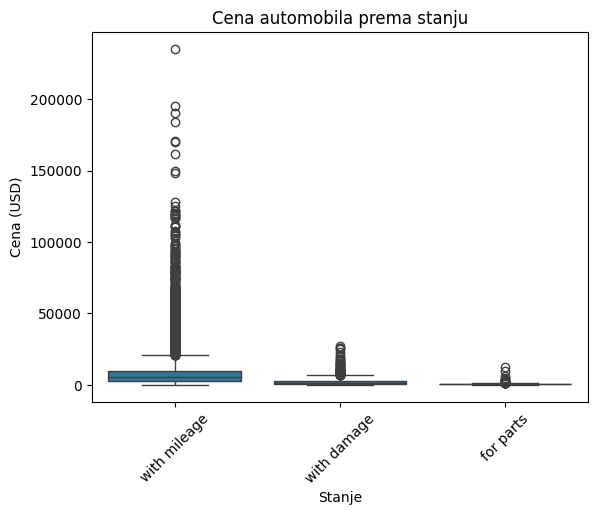

In [99]:
sns.boxplot(data=df, x='condition', y='priceUSD')

plt.title('Cena automobila prema stanju')
plt.xlabel('Stanje')
plt.ylabel('Cena (USD)')
plt.xticks(rotation=45)
plt.show()

Ovde uočavamo da stanje automobila ima značajan uticaj na cenu. Vidimo da kategorije `for parts` i `with damage` uglavnom imaju niže vrednosti cena, dok kategorija `with mileage` obuhvata širi raspon cena i prisutna je u gotovo svim rasponima vrednosti.

## Year prikaz

In [100]:
print(df['year'].sample(10))

53210    2008
54124    1996
12486    2001
44650    1993
4573     2004
11363    2006
22330    2012
1311     1992
9827     1989
48428    2016
Name: year, dtype: int64


In [101]:
print(df['year'].min())
print(df['year'].max())

1910
2019


Vidimo da se godine proizvodnje uglavnom nalaze u realnom rasponu. Najstariji automobil ima godište 1910, dok najnoviji ima godište 2019. Iako je 1910. veoma neuobičajena vrednost za automobil, potrebno ju je dodatno proveriti kako bismo utvrdili da li predstavlja grešku u podacima.

## Mileage prikaz

In [102]:
print(df['mileage(kilometers)'].sample(10))

33763    325000.0
41355     43000.0
38676    260000.0
18966    210000.0
4290      80000.0
50618     42000.0
5972      80000.0
63       290000.0
28864    330000.0
49456       235.0
Name: mileage(kilometers), dtype: float64


In [103]:
print(df['mileage(kilometers)'].min())
print(df['mileage(kilometers)'].max())

0.0
9999999.0


Vidimo da u koloni `mileage(kilometers)` postoji nelogičnost u maksimalnoj vrednosti. Najveća vrednost iznosi `9,999,999 km`, što je nerealno visoka kilometraža za automobil i najverovatnije predstavlja grešku pri unosu podataka.

In [104]:
df[['make', 'model', 'priceUSD', 'year', 'mileage(kilometers)', 'volume(cm3)']].nlargest(30, 'mileage(kilometers)')

,make,model,priceUSD,year,mileage(kilometers),volume(cm3)
1394,audi,80,500,1986,9999999.0,1800.0
1854,audi,100,900,1989,9999999.0,2300.0
5783,peugeot,806,4100,2000,9999999.0,2000.0
6114,lada-vaz,2104,600,1990,9999999.0,1500.0
6465,lada-vaz,2108,295,1990,9999999.0,1100.0
6684,raf,2203,1000,1991,9999999.0,2400.0
10032,bmw,5-seriya,2000,1985,9999999.0,2800.0
10316,bmw,7-seriya,4650,1998,9999999.0,3000.0
11699,audi,a4,3000,1996,9999999.0,1800.0
16705,fiat,brava,1100,1997,9999999.0,1400.0


Detaljnijim pregledom ekstremnih vrednosti u koloni mileage(kilometers) možemo potvrditi da se ne radi o realnim vrednostima kilometraže. Primećujemo da se veoma visoke vrednosti poput 9,999,999, 8,888,888, 7,777,777 i 6,666,666 ponavljaju kroz veći broj zapisa, što ukazuje da su verovatno korišćene kao placeholder vrednosti ili su posledica greške pri unosu. Ove vrednosti će biti potrebno adekvatno obraditi u procesu čišćenja podataka.

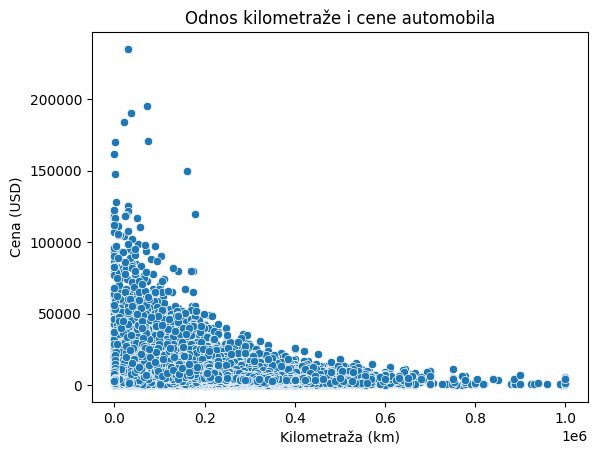

In [105]:
mileage_clean = df[df['mileage(kilometers)'] < 1000000]

sns.scatterplot(
    data=mileage_clean,
    x='mileage(kilometers)',
    y='priceUSD'
)

plt.title('Odnos kilometraže i cene automobila')
plt.xlabel('Kilometraža (km)')
plt.ylabel('Cena (USD)')
plt.show()

Vidimo da postoji negativna veza između kilometraže i cene automobila. Kako kilometraža raste, cena automobila uglavnom opada, što ukazuje na to da kilometraža može imati značajan uticaj na cenu.

## Volume prikaz


In [106]:
print(df['volume(cm3)'].sample(10))

1695     2300.0
1326     2000.0
36432    2000.0
18802    2500.0
40634    1600.0
55948    2000.0
8620     3000.0
20030    1400.0
3269     2000.0
52883    2000.0
Name: volume(cm3), dtype: float64


In [107]:
print(df['volume(cm3)'].min())
print(df['volume(cm3)'].max())

500.0
20000.0


Vidimo da maksimalna vrednost kubikaže iznosi 20.000 cc, što odmah ukazuje na potencijalno nevalidnu vrednost. Ovu vrednost je potrebno dodatno ispitati kako bismo utvrdili da li predstavlja grešku pri unosu podataka.

In [108]:
df[['make', 'model', 'priceUSD', 'year', 'mileage(kilometers)', 'volume(cm3)']].nlargest(30, 'volume(cm3)')

,make,model,priceUSD,year,mileage(kilometers),volume(cm3)
81,mazda,3,5300,2006,168000.0,20000.0
354,mazda,6,7500,2003,240000.0,20000.0
1537,audi,80,2900,1993,392432.0,20000.0
1768,audi,100,2150,1992,300000.0,20000.0
4573,peugeot,407,4600,2004,262900.0,20000.0
4816,volvo,460,750,1994,333000.0,20000.0
5369,mazda,626,1200,1995,425326.0,20000.0
5553,mazda,626,1000,1990,250000.0,20000.0
5607,mazda,626,1200,1989,0.0,20000.0
5908,volvo,940,1521,1997,300000.0,20000.0


Detaljnijim pregledom najvećih vrednosti u koloni `volume(cm3)` potvrđujemo da postoje nelogične vrednosti. Vrednosti od `10.000` do `20.000 cm³` pojavljuju se kod velikog broja različitih automobila, bez obzira na proizvođača, model ili godište. S obzirom na to da su ove vrednosti nerealne za navedene modele i da se ponavljaju u pravilnom obrascu, možemo pretpostaviti da predstavljaju greške pri unosu podataka i da će ih biti potrebno obraditi tokom čišćenja skupa.

## Prikaz kategorijskih kolona

In [109]:
categorical_columns = [
    'make',
    'model',
    'condition',
    'fuel_type',
    'color',
    'transmission',
    'drive_unit',
    'segment'
]

for column in categorical_columns:
    print(column)
    print(df[column].nunique())
    print("-" * 40)

make
96
----------------------------------------
model
1034
----------------------------------------
condition
3
----------------------------------------
fuel_type
3
----------------------------------------
color
13
----------------------------------------
transmission
2
----------------------------------------
drive_unit
4
----------------------------------------
segment
9
----------------------------------------


Pregledom kategorijskih kolona možemo videti da se broj unikatnih vrednosti značajno razlikuje između kolona. Kolona `model` ima najveći broj unikatnih vrednosti, ukupno 1034, dok `make` ima 96 različitih proizvođača. Ostale kategorijske kolone imaju znatno manji broj kategorija: `condition` 3, `fuel_type` 3, `color` 13, `transmission` 2, `drive_unit` 4 i `segment` 9.

In [110]:
for column in categorical_columns:
    print(df[column].value_counts(dropna=False))
    print("-" * 40)

make
volkswagen    6861
audi          4030
bmw           4013
opel          3779
renault       3713
              ... 
mclaren          1
asia             1
jac              1
tagaz            1
saipa            1
Name: count, Length: 96, dtype: int64
----------------------------------------
model
passat      2086
5-seriya    1476
a6          1276
golf        1070
astra       1013
            ... 
x-90           1
xjs            1
180            1
88             1
33             1
Name: count, Length: 1034, dtype: int64
----------------------------------------
condition
with mileage    55278
with damage       512
for parts         454
Name: count, dtype: int64
----------------------------------------
fuel_type
petrol        36405
diesel        19792
electrocar       47
Name: count, dtype: int64
----------------------------------------
color
black       12385
silver      10075
blue         8083
gray         5807
white        5292
green        3911
other        3397
red          2744
bur

Pregledom kategorijskih kolona možemo videti da je zastupljenost vrednosti veoma različita između pojedinih kolona. Kod `make` i `model` postoji veliki broj različitih kategorija, pri čemu se pojedini proizvođači i modeli pojavljuju veoma često, dok se veliki broj njih pojavljuje svega nekoliko puta. Ovo je potrebno uzeti u obzir prilikom kasnijeg encoding-a. Kolona condition je izrazito neuravnotežena, jer najveći broj automobila pripada kategoriji `with mileage`, dok su `with damage` i `for parts` znatno manje zastupljene. Slična neravnomerna zastupljenost postoji i kod `fuel_type`, gde električni automobili čine veoma mali deo skupa. Kod `color`, `transmission`, `drive_unit` i `segment` nema većih problema sa brojem kategorija, ali `drive_unit` i `segment` sadrže određeni broj nedostajućih vrednosti koje će biti potrebno obraditi u procesu čišćenja podataka. Zbog velikog broja retko zastupljenih kategorija kod `make` i posebno `model`, ove kolone ćemo dodatno razmotriti prilikom pripreme podataka i encoding-a.

## Odnos kategorijskih karakteristika sa cenom

## Tip goriva (`fuel_type`)


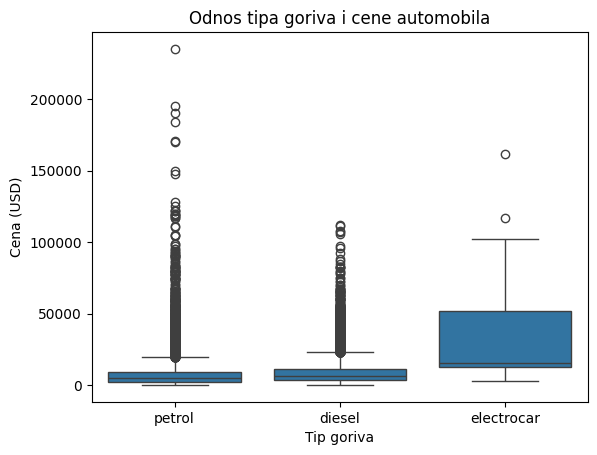

In [111]:
sns.boxplot(
    data=df,
    x='fuel_type',
    y='priceUSD'
)

plt.title('Odnos tipa goriva i cene automobila')
plt.xlabel('Tip goriva')
plt.ylabel('Cena (USD)')
plt.show()

Vidimo da je raspodela cena u kategorijama `petrol` i `diesel` relativno slična, uz nešto veći broj ekstremnih vrednosti u kategoriji `petrol`. Kod kategorije `electrocar` raspodela je šira, ali zbog znatno manjeg broja vozila u ovoj kategoriji rezultate treba uzeti sa rezervom.

## Menjac (transmission)

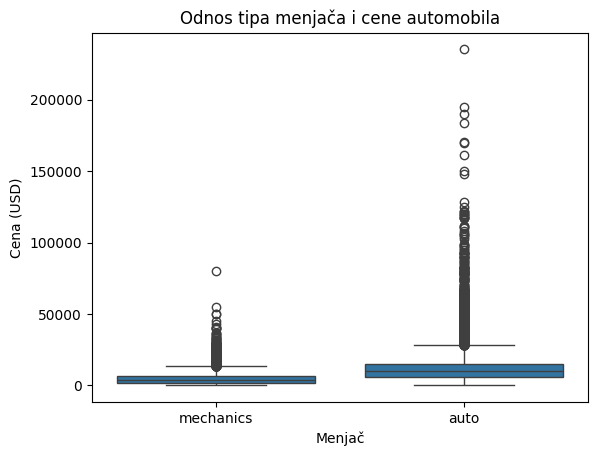

In [112]:
sns.boxplot(
    data=df,
    x='transmission',
    y='priceUSD'
)

plt.title('Odnos tipa menjača i cene automobila')
plt.xlabel('Menjač')
plt.ylabel('Cena (USD)')
plt.show()

Vidimo da je cena automobila sa automatskim menjačem u proseku viša u odnosu na automobile sa manuelnim menjačem. Takođe, kod automatskog menjača postoji znatno veći broj ekstremnih vrednosti.

## Pogon (drive_unit)

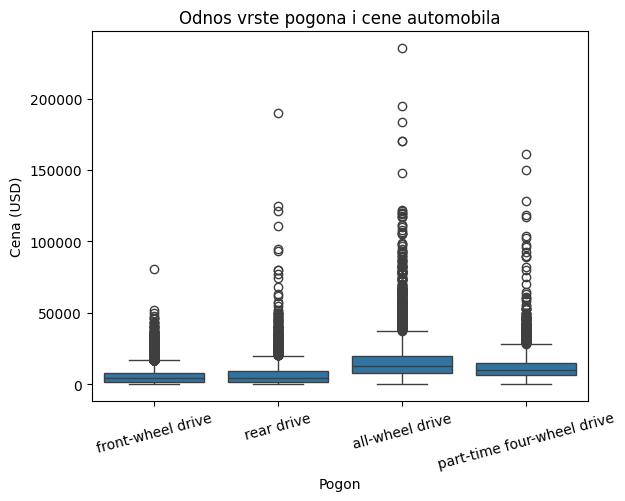

In [113]:
sns.boxplot(
    data=df,
    x='drive_unit',
    y='priceUSD'
)

plt.title('Odnos vrste pogona i cene automobila')
plt.xlabel('Pogon')
plt.ylabel('Cena (USD)')
plt.xticks(rotation=15)
plt.show()

Vidimo da su cene relativno slično raspoređene u većini kategorija. Kod kategorije `all-wheel drive` uočavamo višu prosečnu cenu i širu raspodelu cena u odnosu na ostale kategorije.

## Marka (make)

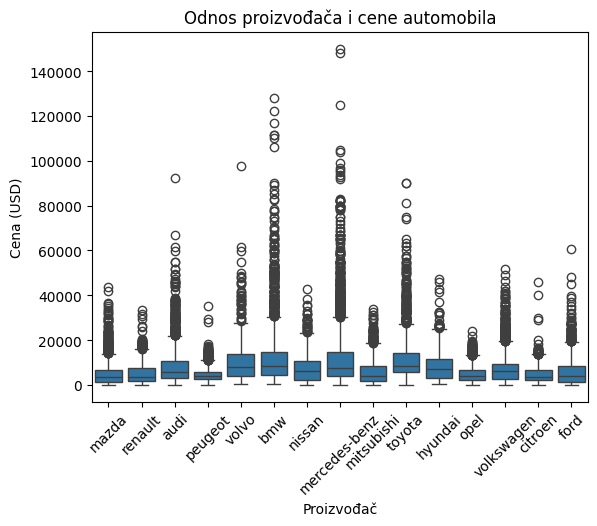

In [114]:
top_makes = df['make'].value_counts().head(15).index

sns.boxplot(
    data=df[df['make'].isin(top_makes)],
    x='make',
    y='priceUSD'
)

plt.title('Odnos proizvođača i cene automobila')
plt.xlabel('Proizvođač')
plt.ylabel('Cena (USD)')
plt.xticks(rotation=45)
plt.show()

Kod najzastupljenijih proizvođača vidimo raznovrsnu raspodelu cena. Proizvođači `Volvo`, `BMW`, `Mercedes-Benz` i `Toyota` imaju širu raspodelu cena i višu medijanu u odnosu na većinu ostalih proizvođača, što može ukazivati na uticaj proizvođača na cenu automobila.

## EDA zakljucak
EDA analizom skupa podataka upoznali smo se sa njegovom strukturom, raspodelom vrednosti i odnosima između različitih karakteristika i ciljne promenljive `priceUSD`. Uočene su nedostajuće vrednosti u nekoliko kolona, kao i određeni broj duplikata koje je potrebno obraditi u procesu čišćenja podataka. Takođe su pronađene nelogične vrednosti, poput ekstremnih vrednosti u kolonama `mileage(kilometers)` i `volume(cm3)`, koje je potrebno dodatno obraditi.

Analizom odnosa karakteristika sa cenom uočeno je da `year`, `mileage(kilometers)` i `condition` imaju primetnu povezanost sa cenom. Kod kategorijskih karakteristika uočene su razlike u raspodeli cena između pojedinih kategorija, posebno kod `transmission`, `drive_unit` i `make`. Sa druge strane, kod `volume(cm3)` nije uočena jasna povezanost sa cenom, ali ćemo ovu kolonu za sada zadržati i njenu korisnost proveriti tokom modelovanja.

Kod `make` i posebno `model` postoji veliki broj različitih kategorija, što će zahtevati pažnju prilikom encoding-a. U narednom procesu potrebno je obraditi nedostajuće i nevalidne vrednosti, ukloniti duplikate i pripremiti kategorijske i numeričke karakteristike za treniranje modela. Konačan uticaj pojedinačnih karakteristika proverićemo kroz poređenje modela sa različitim skupovima feature-a.